In [1]:
!pip install -q shap lime dice-ml alibi scikit-learn pandas numpy matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.5/98.5 MB 8.3 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Φόρτωση tabular δεδομένων
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = list(X.columns)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Απλό baseline μοντέλο
model = RandomForestClassifier(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

# Το δείγμα (instance x) που θέλουμε να εξηγήσουμε τοπικά
instance = X_test.iloc[[0]]
print("Model accuracy:", model.score(X_test, y_test))

Model accuracy: 0.9649122807017544


In [3]:
# --- 1. SHAP (TreeExplainer) ---
import shap
explainer_shap = shap.TreeExplainer(model)
shap_values = explainer_shap(instance)
print("SHAP values shape:", shap_values.values.shape)
# shap.plots.waterfall(shap_values[0]) # Visual output

# --- 2. LIME Tabular ---
from lime.lime_tabular import LimeTabularExplainer
explainer_lime = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=feature_names,
    class_names=['Malignant', 'Benign'],
    mode='classification'
)
lime_exp = explainer_lime.explain_instance(
    data_row=instance.values[0],
    predict_fn=model.predict_proba,
    num_features=5
)
print("LIME rules:", lime_exp.as_list())

# --- 3. DiCE (Counterfactuals) ---
import dice_ml
d = dice_ml.Data(
    dataframe=pd.concat([X_train, y_train], axis=1),
    continuous_features=feature_names,
    outcome_name='target'
)
m = dice_ml.Model(model=model, backend="sklearn")
exp_dice = dice_ml.Dice(d, m, method="random")
cf = exp_dice.generate_counterfactuals(instance, total_CFs=2, desired_class="opposite")
cf.visualize_as_dataframe(show_only_changes=True)

SHAP values shape: (1, 30, 2)


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


LIME rules: [('516.45 < worst area <= 686.60', 0.06942644081580933), ('84.25 < worst perimeter <= 97.67', 0.05751498100976905), ('13.05 < worst radius <= 14.97', 0.04113248150167841), ('0.10 < worst concave points <= 0.16', 0.02674345408913058), ('420.30 < mean area <= 551.70', 0.016734160088167135)]


100%|██████████| 1/1 [00:00<00:00,  2.71it/s]

Query instance (original outcome : 1)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,12.47,18.6,81.089996,481.899994,0.09965,0.1058,0.08005,0.03821,0.1925,0.06373,...,24.639999,96.050003,677.900024,0.1426,0.2378,0.2671,0.1015,0.3014,0.0875,1



Diverse Counterfactual set (new outcome: 0)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,-,-,-,-,-,-,-,-,-,-,...,-,-,2764.4,-,-,-,0.2,-,-,0.0
1,-,-,-,-,-,-,-,-,-,-,...,-,226.6,3078.0,-,-,-,-,-,-,0.0


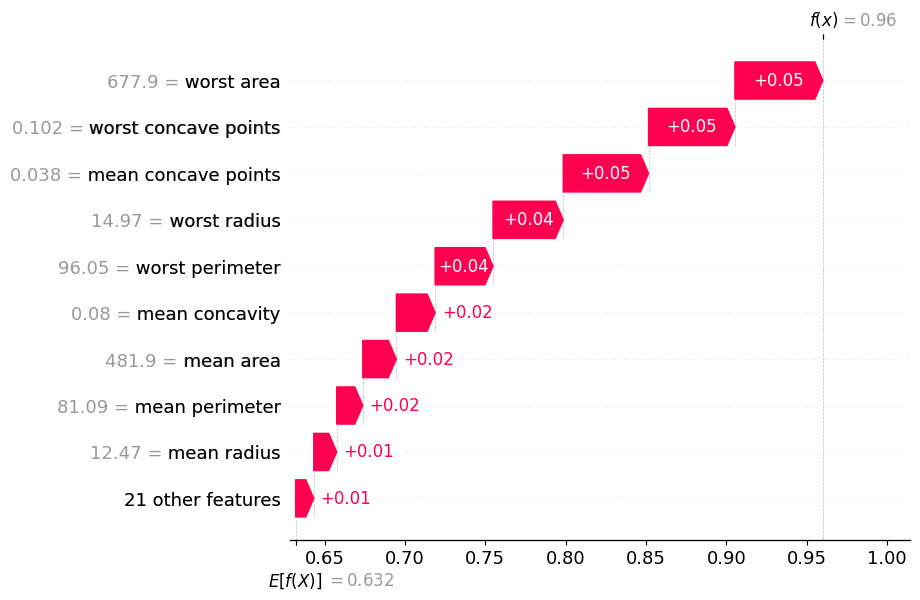

In [5]:
# Κώδικας για οπτικοποίηση Waterfall Plot στο Google Colab
import shap

# Υπολογισμός SHAP τιμών για το πρώτο δείγμα (instance)
# Για classification με 2 κλάσεις, επιλέγουμε την κλάση ενδιαφέροντος (π.χ. κλάση 1 - Benign)
shap_explanation = explainer_shap(instance)

# Waterfall Plot για το 1ο δείγμα και την κλάση 1
shap.plots.waterfall(shap_explanation[0, :, 1])

Τεχνικές Προδιαγραφές XAI & Προσαρμογές Διαγράμματος

1. Τεχνικές Προδιαγραφές Μεθόδων

SHAP
- Required Inputs: model.predict ή Tree object, Background dataset (X_bg για KernelExplainer), δείγμα x.
- Output: Διάνυσμα προσθετικών αποδόσεων Shapley (phi_i), Base Value. Visuals: Waterfall, Force Plot, Beeswarm, Summary Bar, Dependence Plot.
- Configurations: nsamples, link, feature_perturbation.
- Limitations: Υψηλό υπολογιστικό κόστος στο KernelSHAP, υπόθεση ανεξαρτησίας χαρακτηριστικών.

LIME
- Required Inputs: model.predict_proba (Callable), Matrix εκπαίδευσης (X_train), δείγμα x.
- Output: Λίστα τοπικών βαρών [(rule_i, w_i)], Local Fidelity (R^2). Visuals: Horizontal Bar Chart.
- Configurations: num_samples, kernel_width, discretize_continuous.
- Limitations: Αστάθεια λόγω τοπικής δειγματοληψίας, παραδοχή τοπικής γραμμικότητας.

DiCE (Counterfactuals)
- Required Inputs: model.predict_proba ή predict, Tabular DataFrame, δείγμα x, επιθυμητός στόχος (desired_class ή range).
- Output: DataFrame με εναλλακτικά διανύσματα x' (What-If table).
- Configurations: total_CFs, features_to_vary, permitted_range, method (random, genetic, kdtree).
- Limitations: Απαιτεί ρητά metadata (immutables, bounds) για να μην εξάγει ανέφικτες λύσεις.

Anchors
- Required Inputs: model.predict, Dataset εκπαίδευσης για binning, δείγμα x.
- Output: Κανόνας IF-THEN, Precision score, Coverage score. Visuals: Κείμενο κανόνα φυσικής γλώσσας.
- Configurations: threshold (tau >= 0.95), beam_size, delta.
- Limitations: Αποκλειστικά για classification, απαιτεί διακριτοποίηση συνεχών μεταβλητών.

ALE
- Required Inputs: model.predict, Dataset X, Target Feature.
- Output: Διάνυσμα διαφορικών επιδράσεων y_ALE. Visuals: 1D Line Plot ή 2D Surface Plot.
- Configurations: grid_size / bins (quantiles).
- Limitations: Μόνο Global ανάλυση, ευαισθησία σε αραιά bins.

2. Προσαρμογές Παραμέτρων & Ροών στο Διάγραμμα

- Model Interface Wrapper: Εισαγωγή επιπέδου προσαρμογέα για ομογενοποίηση κλήσεων σε predict και predict_proba.
- Background Sampler: Προσθήκη K-Means clustering (100 centroids) στο reference dataset για αποφυγή καθυστερήσεων στο KernelSHAP.
- Διαχωρισμός Εξόδων (Visual vs Data Flow):
  * Οπτική ροή (διαγράμματα) απευθείας στο UI των χρηστών.
  * Αριθμητική ροή (raw JSON, arrays, κανόνες) προς το LLM Prompt Context.
- Metadata Routing: Σύνδεση των παραμέτρων (κλειδωμένες στήλες, όρια τιμών) αποκλειστικά προς DiCE και Anchors.
- Multi-Output Decomposition: Μηχανισμός 1-προς-N για μοντέλα πολλαπλών στόχων, με διαδοχική εκτέλεση ανά έξοδο.
- Assessment Layer: Σύνδεση των παραγόμενων attributions στις μετρικές αξιολόγησης (Faithfulness, Robustness, Compactness) πριν την τελική σύνοψη.